In [81]:
import h5py
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path
import os

In [40]:
path_to_testfile = "../../data/Hubbard/corrs/N256_U0.100_Vpp0.800_Vpm4.350_Np128_corrs.h5"
pd.__version__
data = {}


def load_hdf5(group):
    result = {}

    for key, obj in group.items():
        if isinstance(obj, h5py.Dataset):
            result[key] = obj[()]
        elif isinstance(obj, h5py.Group):
            result[key] = load_hdf5(obj)

    return result


with h5py.File(path_to_testfile, "r") as f:
    data = load_hdf5(f)

data.keys()


dict_keys(['chargemat', 'elecdnmat', 'elecupmat', 'ntot_expect', 'params', 'spin2vec', 'spmmat', 'sz_expect', 'szmat', 'xspin2'])

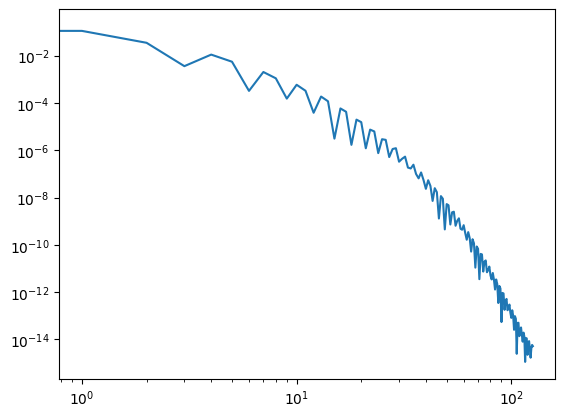

In [43]:
plt.plot(np.abs(data["elecupmat"][128, 129:]))
plt.yscale("log")
plt.xscale("log")

In [89]:
import h5py
import pandas as pd


def load_correlations(path):

    with h5py.File(path, "r") as f:
        tdict = {
            "szmat":       f["szmat"][()],
            "chargemat":   f["chargemat"][()],
            "spmmat":      f["spmmat"][()],
            "elecupmat":   f["elecupmat"][()],
            "elecdnmat":   f["elecdnmat"][()],
            "sz_expect":   f["sz_expect"][()],
            "ntot_expect": f["ntot_expect"][()],
            "xspin2":      f["xspin2"][()] if "xspin2" in f else None,
            "spin2vec":    f["spin2vec"][()] if "spin2vec" in f else None,
        }
        N = tdict["szmat"].shape[0]
        print(type(tdict["szmat"]), type(tdict["sz_expect"]))
        tdict["szconn"] = tdict["szmat"][N//2, N//2 : ] 
        - tdict["sz_expect"][N//2] * tdict["sz_expect"][N//2: ]
        tdict["chargeconn"] = tdict["chargemat"][N//2, N//2 : ]
        - tdict["ntot_expect"][N//2] * tdict["ntot_expect"][N//2: ]
        
    
    return tdict

def load_correlations_files(paths):
    """Load multiple correlation files into a DataFrame."""

    rows = []

    for path in paths:
        row = load_correlations(path)
        row["filename"] = path
        rows.append(row)

    return pd.DataFrame(rows)



def corr_filename_builder(
    N, t, U, Vpp, dV, prefix="data/Hubbard/", DATAROOT="../../"
):
    Vpm = Vpp + dV
    Npart = N // 2

    prefix = Path(prefix)

    if "ImpPrec" in prefix.parts:
        outdir = Path("data") / "Hubbard" / "corrs_imp"
    else:
        outdir = prefix / "corrs"

    filename = (
        f"N{N}"
        f"_U{U:.3f}"
        f"_Vpp{Vpp:.3f}"
        f"_Vpm{Vpm:.3f}"
        f"_Np{Npart}"
        "_corrs.h5"
    )

    return os.path.join(DATAROOT, os.path.join(outdir, filename))


In [74]:
load_correlations_files([path_to_testfile]).iloc[0]

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


szmat          [[0.10819832214045556, -0.007893957727545038, ...
chargemat      [[0.7153209943999193, 0.057674065474220604, 0....
spmmat         [[0.21639643687302024, -0.022053048825553565, ...
elecupmat      [[0.2870283633325445, 0.24864616678023996, 0.1...
elecdnmat      [[0.2870287781483263, 0.24864651441281782, 0.1...
sz_expect      [-2.0740789089413597e-07, -1.8113844273240811e...
ntot_expect    [0.5740571414808707, 0.6164069115921222, 0.419...
xspin2         [130, 131, 132, 133, 134, 135, 136, 137, 138, ...
spin2vec       [(1.9908329962592232e-05+0j), (0.0001883989282...
szconn         [0.08921901032211732, -0.0005955280761851766, ...
chargeconn     [0.6408395031170183, 0.07090063951647482, 0.25...
filename       ../../data/Hubbard/corrs/N256_U0.100_Vpp0.800_...
Name: 0, dtype: object

In [88]:
load_correlations_files(
    [corr_filename_builder(N=256, t=1.0, U=0.1, Vpp=0.8, dV=3.55, DATAROOT="../../")])

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


,szmat,chargemat,spmmat,elecupmat,elecdnmat,sz_expect,ntot_expect,xspin2,spin2vec,szconn,chargeconn,filename
0,"[[0.10819832214045556, -0.007893957727545038, ...","[[0.7153209943999193, 0.057674065474220604, 0....","[[0.21639643687302024, -0.022053048825553565, ...","[[0.2870283633325445, 0.24864616678023996, 0.1...","[[0.2870287781483263, 0.24864651441281782, 0.1...","[-2.0740789089413597e-07, -1.8113844273240811e...","[0.5740571414808707, 0.6164069115921222, 0.419...","[130, 131, 132, 133, 134, 135, 136, 137, 138, ...","[(1.9908329962592232e-05+0j), (0.0001883989282...","[0.08921901032211732, -0.0005955280761851766, ...","[0.6408395031170183, 0.07090063951647482, 0.25...",../../data/Hubbard/corrs/N256_U0.100_Vpp0.800_...
